In [12]:
from data_preparation import prepare_dataset, get_loss_weights
from graph_construction import build_graph
from train_and_evaluate import (
    train_and_evaluate,
    train_mlp
)
from models import (
    BaselineMLP,
    GoldenTransformer
)
from resources import (
    DATA_PATH,
    DEVICE,
    OUTPUT_TABLES_PATH,
    OUTPUT_FIGURES_PATH
)

EPOCHS = 500
PATIENCE = 30

In [13]:
import pandas as pd
import torch
import os
import numpy as np

In [ ]:
x, y, pos_combined, pos_spatial, pos_temporal, group_ids = prepare_dataset(DATA_PATH, return_group_ids=True)
class_weights = get_loss_weights(y = y)

There are 10034 natural fires (56.44 %) [all]
There are 7744 human made fires (43.56 %) [all]


In [15]:
mlp_topology_comparison_df = pd.read_csv(os.path.join(OUTPUT_TABLES_PATH, "mlp_topology_comparison.csv"))
topology_comparison_df = pd.read_csv(os.path.join(OUTPUT_TABLES_PATH, "topology_comparison_df.csv"))

# FULL FEATURE INTEGRATION

## Finding the Best Transformer

In [16]:
head_list=[2, 4, 8]
k_list=[5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35]

In [17]:
def run_golden_integrated_study(head_list, k_list):
    print("\n" + "="*60)
    print("STAGE 3: GOLDEN GRID SEARCH (HEADS x K) - FULL CAUSAL INTEGRITY")
    print("="*60)

    # 1. Prepare Full Features [Log-Area, Lat, Lon, Days]
    # Ensure all are on the same device and correctly shaped
    log_area_t = x.to(DEVICE) if x.dim() == 2 else x.unsqueeze(1).to(DEVICE)
    x_full = torch.cat([
        log_area_t, 
        pos_spatial.to(DEVICE), 
        pos_temporal.to(DEVICE)
    ], dim=1)

    final_results = []

    for k in k_list:
        data_k = build_graph('multirelational', k, pos_spatial, pos_temporal, pos_combined, x_full, y, group_ids=group_ids)
        data_k = data_k.to(DEVICE)
        
        in_dim = data_k.x.size(1)       
        e_dim = data_k.edge_attr.size(1) 

        for h in head_list:
            print(f"\n>>> Training: multirelational K={k} | Heads={h} | Dim: {in_dim} in / {e_dim} edge")
            
            model = GoldenTransformer(
                input_dim=in_dim, 
                hidden_dim=16, 
                edge_dim=e_dim, 
                num_heads=h
            )
            
            f1, acc, __ = train_and_evaluate(model, data_k, DEVICE, class_weights, max_epochs=500, patience=30)
            
            print(f"RESULTS | K: {k:<2} | Heads: {h:<2} | F1: {f1:.4f} | Acc: {acc:.4f}")

            final_results.append({
                'K': k,
                'Heads': h,
                'Model': f'Transformer_{h}H_K{k}',
                'F1': f1,
                'Accuracy': acc
            })

    # 3. Summary and Comparison vs Best MLP
    best_transformer_df = pd.DataFrame(final_results)
    best_gnn = best_transformer_df.sort_values(by='F1', ascending=False).iloc[0]

    mlp_subset = mlp_topology_comparison_df[mlp_topology_comparison_df['Model'] == 'MLP']
    if not mlp_subset.empty:
        mlp_best = mlp_subset.sort_values(by='F1', ascending=False).iloc[0]

        print("\n" + "="*60)
        print("FINAL COMPETITIVE SUMMARY: GNN vs. BASELINE")
        print("-" * 60)
        print(f"Best MLP Baseline F1:     {mlp_best['F1']:.4f}")
        print(f"Golden GNN Winner F1:     {best_gnn['F1']:.4f} (K={best_gnn['K']}, Heads={best_gnn['Heads']})")
        
        f1_lift = best_gnn['F1'] - mlp_best['F1']
        
        print(f"Total F1 Score Lift:      {f1_lift*100:+.2f}%")
        print("="*60)
    
    return best_transformer_df

best_transformer_df = run_golden_integrated_study(
    head_list=head_list,
    k_list=k_list
)
best_transformer_df.to_csv(os.path.join(OUTPUT_TABLES_PATH, "best_transformer_df.csv"))


STAGE 3: GOLDEN GRID SEARCH (HEADS x K) - FULL CAUSAL INTEGRITY

>>> Training: multirelational K=5 | Heads=2 | Dim: 4 in / 4 edge
RESULTS | K: 5  | Heads: 2  | F1: 0.6330 | Acc: 0.6665

>>> Training: multirelational K=5 | Heads=4 | Dim: 4 in / 4 edge
RESULTS | K: 5  | Heads: 4  | F1: 0.6704 | Acc: 0.6847

>>> Training: multirelational K=5 | Heads=8 | Dim: 4 in / 4 edge
RESULTS | K: 5  | Heads: 8  | F1: 0.6347 | Acc: 0.6564

>>> Training: multirelational K=7 | Heads=2 | Dim: 4 in / 4 edge
RESULTS | K: 7  | Heads: 2  | F1: 0.6817 | Acc: 0.7004

>>> Training: multirelational K=7 | Heads=4 | Dim: 4 in / 4 edge
RESULTS | K: 7  | Heads: 4  | F1: 0.6550 | Acc: 0.6808

>>> Training: multirelational K=7 | Heads=8 | Dim: 4 in / 4 edge
RESULTS | K: 7  | Heads: 8  | F1: 0.6705 | Acc: 0.6936

>>> Training: multirelational K=9 | Heads=2 | Dim: 4 in / 4 edge
RESULTS | K: 9  | Heads: 2  | F1: 0.6845 | Acc: 0.6948

>>> Training: multirelational K=9 | Heads=4 | Dim: 4 in / 4 edge
RESULTS | K: 9  | Head

## Best MLP vs Best GNN (Full Node Features): Multi-Metric Comparison

In [22]:
best_transformer_df = pd.read_csv(os.path.join(OUTPUT_TABLES_PATH, "best_transformer_df.csv"))

In [23]:
x_mlp_spatial = torch.cat([x, pos_spatial], dim=1)        
x_mlp_temporal = torch.cat([x, pos_temporal], dim=1)        
x_mlp_combined = torch.cat([x, pos_spatial, pos_temporal], dim=1) 

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, matthews_corrcoef, balanced_accuracy_score
import random
import numpy as np
import torch

def run_automated_showdown(best_transformer_df, mlp_topology_comparison_df, x_mlp_combined, x_mlp_spatial, x_mlp_temporal, num_runs=5):
    log_area_t = x.to(DEVICE) if x.dim() == 2 else x.unsqueeze(1).to(DEVICE)
    print(log_area_t)
    x_full = torch.cat([
        log_area_t, 
        pos_spatial.to(DEVICE), 
        pos_temporal.to(DEVICE)
    ], dim=1)

    print("\n" + "!"*60)
    print(f"STAGE 4: FINAL COMPARISON (N={num_runs})")
    print("!"*60)

    # 1. IDENTIFY BEST MODELS
    best_gnn_row = best_transformer_df.sort_values(by='F1', ascending=False).iloc[0]
    best_k, best_h = int(best_gnn_row['K']), int(best_gnn_row['Heads'])
    
    best_mlp_row = mlp_topology_comparison_df[mlp_topology_comparison_df['Model'] == 'MLP'].sort_values(by='F1', ascending=False).iloc[0]
    best_mlp_type = best_mlp_row['Graph']

    mlp_feature_map = {
        'MLP_Combined': (x_mlp_combined, x_mlp_combined.size(1)),
        'MLP_Spatial': (x_mlp_spatial, x_mlp_spatial.size(1)),
        'MLP_Temporal': (x_mlp_temporal, x_mlp_temporal.size(1))
    }
    mlp_features, mlp_in_dim = mlp_feature_map[best_mlp_type]

    print(f"\n[CHAMPIONS]")
    print(f"GNN: Transformer (K={best_k}, Heads={best_h})")
    print(f"MLP: {best_mlp_type} (Input Dim={mlp_in_dim})")

    # 2. INITIALIZE RESULTS STORAGE
    # We track 5 metrics for both models
    metrics = ['F1', 'Acc', 'Balanced_Acc', 'AUC', 'MCC']
    results = {model: {m: [] for m in metrics} for model in ['GNN', 'MLP']}
    
    seeds = [111, 333, 555, 777, 999]
    data_final = build_graph('multirelational', best_k, pos_spatial, pos_temporal, pos_combined, x_full, y, group_ids=group_ids).to(DEVICE)
    train_mask = data_final.train_mask.to(DEVICE)
    val_mask = data_final.val_mask.to(DEVICE)
    test_mask = data_final.test_mask.to(DEVICE)

    # 3. THE COMPARISON
    for i in range(num_runs):
        seed = seeds[i]
        
        # GNN Evaluation
        set_seed(seed)
        model_gnn = GoldenTransformer(
            input_dim=data_final.x.size(1), 
            hidden_dim=16, 
            edge_dim=data_final.edge_attr.size(1), 
            num_heads=best_h
        ).to(DEVICE)
        
        _, _, trained_gnn = train_and_evaluate(model_gnn, data_final, DEVICE, class_weights, max_epochs=500, patience=30)
        
        gnn_m = calculate_binary_metrics(trained_gnn, data_final, test_mask, is_gnn=True)
        for m in metrics: results['GNN'][m].append(gnn_m[m])

        # MLP Evaluation
        set_seed(seed)
        model_mlp = BaselineMLP(input_dim=mlp_in_dim, hidden_dim=16).to(DEVICE)
        _, _, trained_mlp = train_mlp(model_mlp, mlp_features, y, train_mask, val_mask, test_mask, DEVICE, class_weights)
        
        mlp_m = calculate_binary_metrics(trained_mlp, (mlp_features, y), test_mask, is_gnn=False)
        for m in metrics: results['MLP'][m].append(mlp_m[m])
        
        print(f"Run {i+1}/{num_runs} | Seed {seed} | GNN F1: {gnn_m['F1']:.4f} | MLP F1: {mlp_m['F1']:.4f}")

    # 4. FINAL REPORTING
    print("\n" + "="*65)
    print(f"{'Metric':<15} | {'Best MLP (Mean +/- SD)':<25} | {'Golden GNN (Mean +/- SD)':<25}")
    print("-" * 65)
    
    final_summary = {}
    for m in metrics:
        g_mean, g_std = np.mean(results['GNN'][m]), np.std(results['GNN'][m])
        m_mean, m_std = np.mean(results['MLP'][m]), np.std(results['MLP'][m])
        final_summary[m] = (g_mean, g_std, m_mean, m_std)
        print(f"{m:<15} | {m_mean:.4f} +/- {m_std:.4f} | {g_mean:.4f} +/- {g_std:.4f}")
    
    lift = ((final_summary['F1'][0] - final_summary['F1'][2]) / final_summary['F1'][2]) * 100
    print("-" * 65)
    print(f"Relative F1 Lift: {lift:+.2f}%")
    print("="*65)

    return results, final_summary

def calculate_binary_metrics(model, data_obj, mask, is_gnn=True):
    """ Helper to compute all 5 metrics for a trained model """
    model.eval()
    device = next(model.parameters()).device
    
    with torch.no_grad():
        if is_gnn:
            data_obj = data_obj.to(device)
            logits = model(data_obj.x, data_obj.edge_index, data_obj.edge_attr)
            y_true = data_obj.y[mask].cpu().numpy()
        else:
            features, y_all = data_obj
            features = features.to(device)
            y_all = y_all.to(device)       
            
            logits = model(features)
            y_true = y_all[mask].cpu().numpy()
            
        probs = torch.softmax(logits[mask], dim=1)[:, 1].cpu().numpy()
        preds = logits[mask].argmax(dim=1).cpu().numpy()

    return {
        'F1': f1_score(y_true, preds, average='macro'),
        'Acc': accuracy_score(y_true, preds),
        'Balanced_Acc': balanced_accuracy_score(y_true, preds),
        'AUC': roc_auc_score(y_true, probs),
        'MCC': matthews_corrcoef(y_true, preds)
    }

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

showdown_results, summary = run_automated_showdown(
    best_transformer_df, 
    mlp_topology_comparison_df, 
    x_mlp_combined, 
    x_mlp_spatial, 
    x_mlp_temporal, 
    num_runs=5
)

print("\n[SUMMARY TABLE]")
best_mlp_vs_full_feature_best_gnn_df = pd.DataFrame(summary, index=['GNN_Mean', 'GNN_SD', 'MLP_Mean', 'MLP_SD']).T
best_mlp_vs_full_feature_best_gnn_df.to_csv(os.path.join(OUTPUT_TABLES_PATH, "best_mlp_vs_full_feature_best_gnn_df.csv"))

tensor([[4.8434],
        [6.3846],
        [7.1095],
        ...,
        [5.8457],
        [8.1252],
        [5.9272]], device='cuda:0')

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
STAGE 4: FINAL COMPARISON (N=5)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

[CHAMPIONS]
GNN: Transformer (K=35, Heads=4)
MLP: MLP_Spatial (Input Dim=3)
Run 1/5 | Seed 111 | GNN F1: 0.7106 | MLP F1: 0.5763
Run 2/5 | Seed 333 | GNN F1: 0.7184 | MLP F1: 0.5815
Run 3/5 | Seed 555 | GNN F1: 0.7169 | MLP F1: 0.5219
Run 4/5 | Seed 777 | GNN F1: 0.7147 | MLP F1: 0.5063
Run 5/5 | Seed 999 | GNN F1: 0.7202 | MLP F1: 0.6040

Metric          | Best MLP (Mean +/- SD)    | Golden GNN (Mean +/- SD) 
-----------------------------------------------------------------
F1              | 0.5580 +/- 0.0374 | 0.7162 +/- 0.0033
Acc             | 0.5950 +/- 0.0379 | 0.7228 +/- 0.0046
Balanced_Acc    | 0.5676 +/- 0.0365 | 0.7151 +/- 0.0031
AUC             | 0.6059 +/- 0.0429 | 0.7869 +/- 0.0065
M

/tmp/ipykernel_24693/605241758.py:30: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


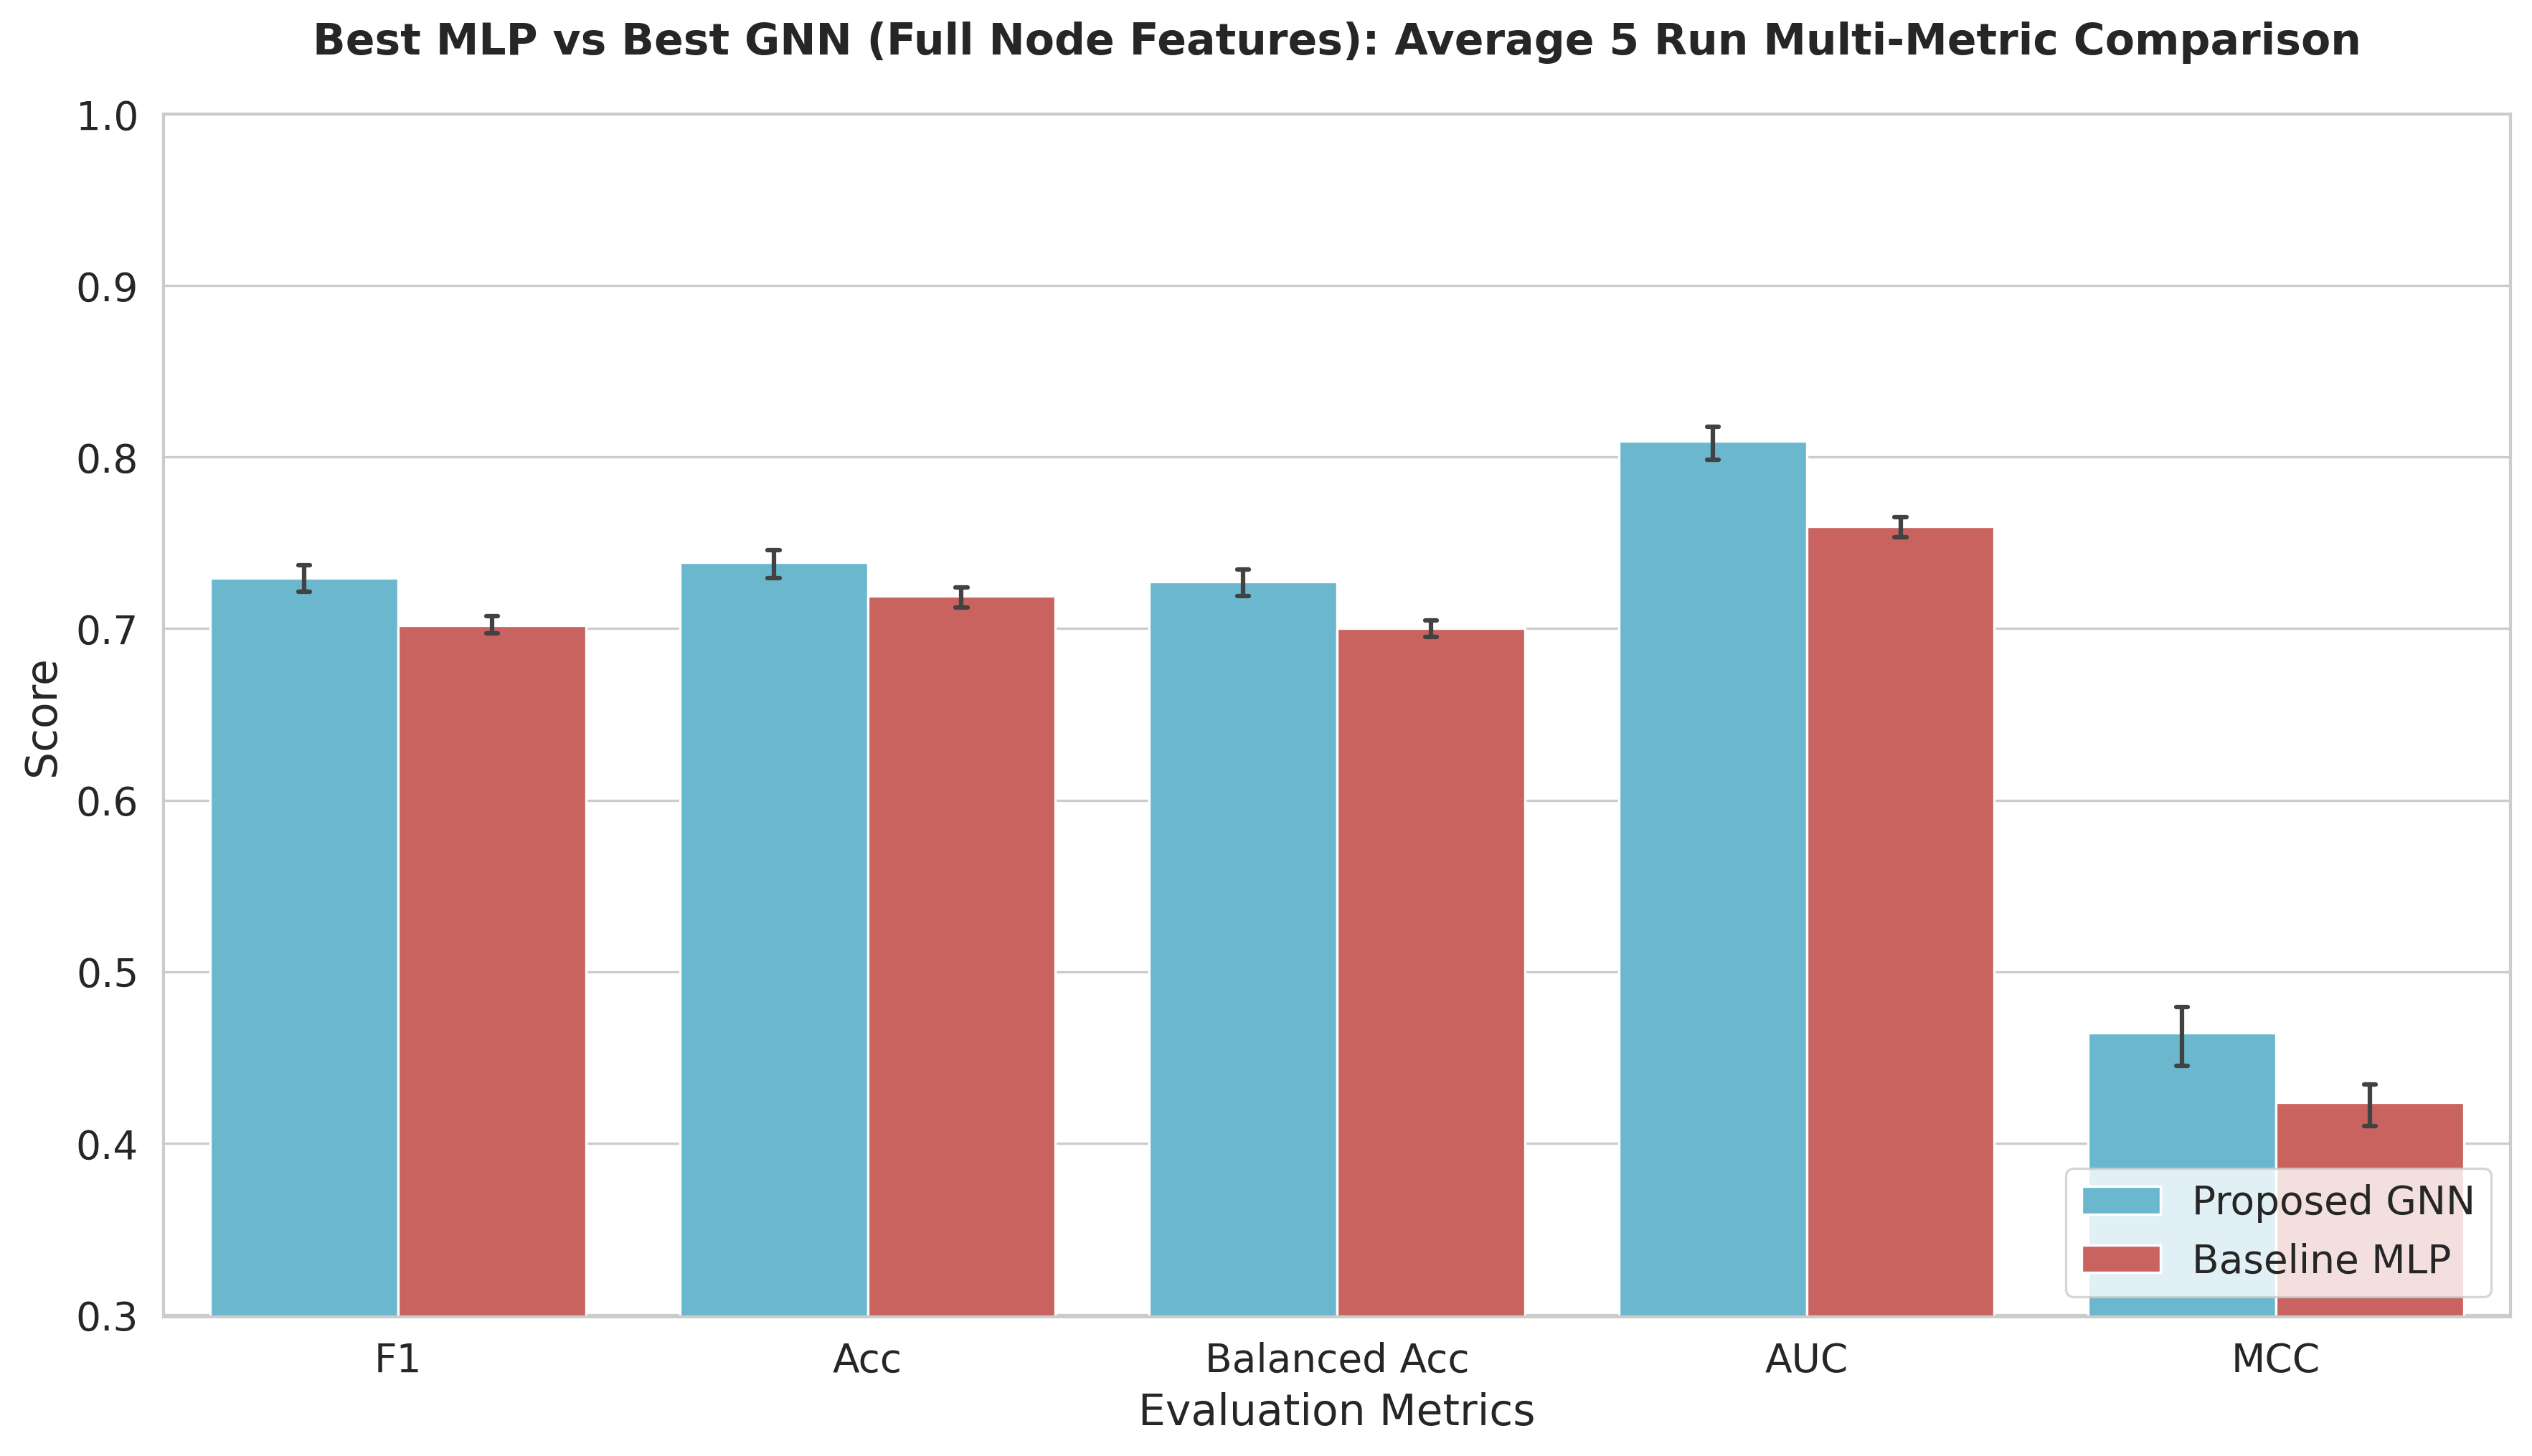


--- Final showdown plots saved to ./outputs/figures ---


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

def plot_final_showdown(showdown_results, OUTPUT_FIGURES_PATH):
    if not os.path.exists(OUTPUT_FIGURES_PATH):
        os.makedirs(OUTPUT_FIGURES_PATH)

    # 1. Transform dictionary results into a Long-Format DataFrame for Seaborn
    plot_data = []
    for model_name, metrics_dict in showdown_results.items():
        for metric_name, values in metrics_dict.items():
            for val in values:
                plot_data.append({
                    'Model': 'Proposed GNN' if model_name == 'GNN' else 'Baseline MLP',
                    'Metric': metric_name.replace('_', ' '),
                    'Score': val
                })
    
    df_plot = pd.DataFrame(plot_data)

    # Set IEEE publication style
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)
    
    # ---------------------------------------------------------
    # PLOT A: COMPREHENSIVE METRIC SHOWDOWN (BARS + ERROR BARS)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7), dpi=300)
    ax = sns.barplot(
        data=df_plot, 
        x='Metric', 
        y='Score', 
        hue='Model', 
        palette=['#5bc0de', '#d9534f'], # Cyan for GNN, Red for MLP
        capsize=.05,
        errwidth=1.5
    )
    
    plt.title("Best MLP vs Best GNN (Full Node Features): Average 5 Run Multi-Metric Comparison", fontweight='bold', pad=20)
    plt.ylabel("Score")
    plt.xlabel("Evaluation Metrics")
    plt.ylim(df_plot['Score'].min() - 0.1, 1.0)
    plt.legend(loc='lower right', frameon=True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FIGURES_PATH, "05_full_node_features_best_gnn_metric_showdown.png"))
    plt.show()

    print(f"\n--- Final showdown plots saved to {OUTPUT_FIGURES_PATH} ---")

# Execute the plotting
plot_final_showdown(showdown_results, OUTPUT_FIGURES_PATH)

## Best MLP vs Best GNN (Full Node Features With Seasonal Features Included): Multi-Metric Comparison

In [30]:
x, y, pos_combined, pos_spatial, pos_temporal, group_ids = prepare_dataset(DATA_PATH, return_group_ids=True, seasonal_features=True)

x_mlp_spatial = torch.cat([x, pos_spatial], dim=1)        
x_mlp_temporal = torch.cat([x, pos_temporal], dim=1)        
x_mlp_combined = torch.cat([x, pos_spatial, pos_temporal], dim=1) 

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

showdown_results_seasonal, summary = run_automated_showdown(
    best_transformer_df, 
    mlp_topology_comparison_df, 
    x_mlp_combined, 
    x_mlp_spatial, 
    x_mlp_temporal, 
    num_runs=5
)

print("\n[SUMMARY TABLE]")
best_mlp_vs_full_feature_best_gnn_seasonal_df = pd.DataFrame(summary, index=['GNN_Mean', 'GNN_SD', 'MLP_Mean', 'MLP_SD']).T
best_mlp_vs_full_feature_best_gnn_seasonal_df.to_csv(os.path.join(OUTPUT_TABLES_PATH, "best_mlp_vs_full_feature_best_gnn_seasonal_df.csv"))

tensor([[ 4.8434,  0.9811,  0.1934],
        [ 6.3846,  0.9992,  0.0398],
        [ 7.1095,  0.9373, -0.3484],
        ...,
        [ 5.8457, -0.4052,  0.9142],
        [ 8.1252, -0.3251,  0.9457],
        [ 5.9272, -0.3251,  0.9457]], device='cuda:0')

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
STAGE 4: FINAL COMPARISON (N=5)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

[CHAMPIONS]
GNN: Transformer (K=35, Heads=4)
MLP: MLP_Spatial (Input Dim=5)
Run 1/5 | Seed 111 | GNN F1: 0.7334 | MLP F1: 0.7045
Run 2/5 | Seed 333 | GNN F1: 0.7251 | MLP F1: 0.7082
Run 3/5 | Seed 555 | GNN F1: 0.7361 | MLP F1: 0.7076
Run 4/5 | Seed 777 | GNN F1: 0.7143 | MLP F1: 0.6945
Run 5/5 | Seed 999 | GNN F1: 0.7393 | MLP F1: 0.6954

Metric          | Best MLP (Mean +/- SD)    | Golden GNN (Mean +/- SD) 
-----------------------------------------------------------------
F1              | 0.7020 +/- 0.0059 | 0.7297 +/- 0.0090
Acc             | 0.7188 +/- 0.0066 | 0.7386 +/- 0.0092

/tmp/ipykernel_24693/605241758.py:30: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


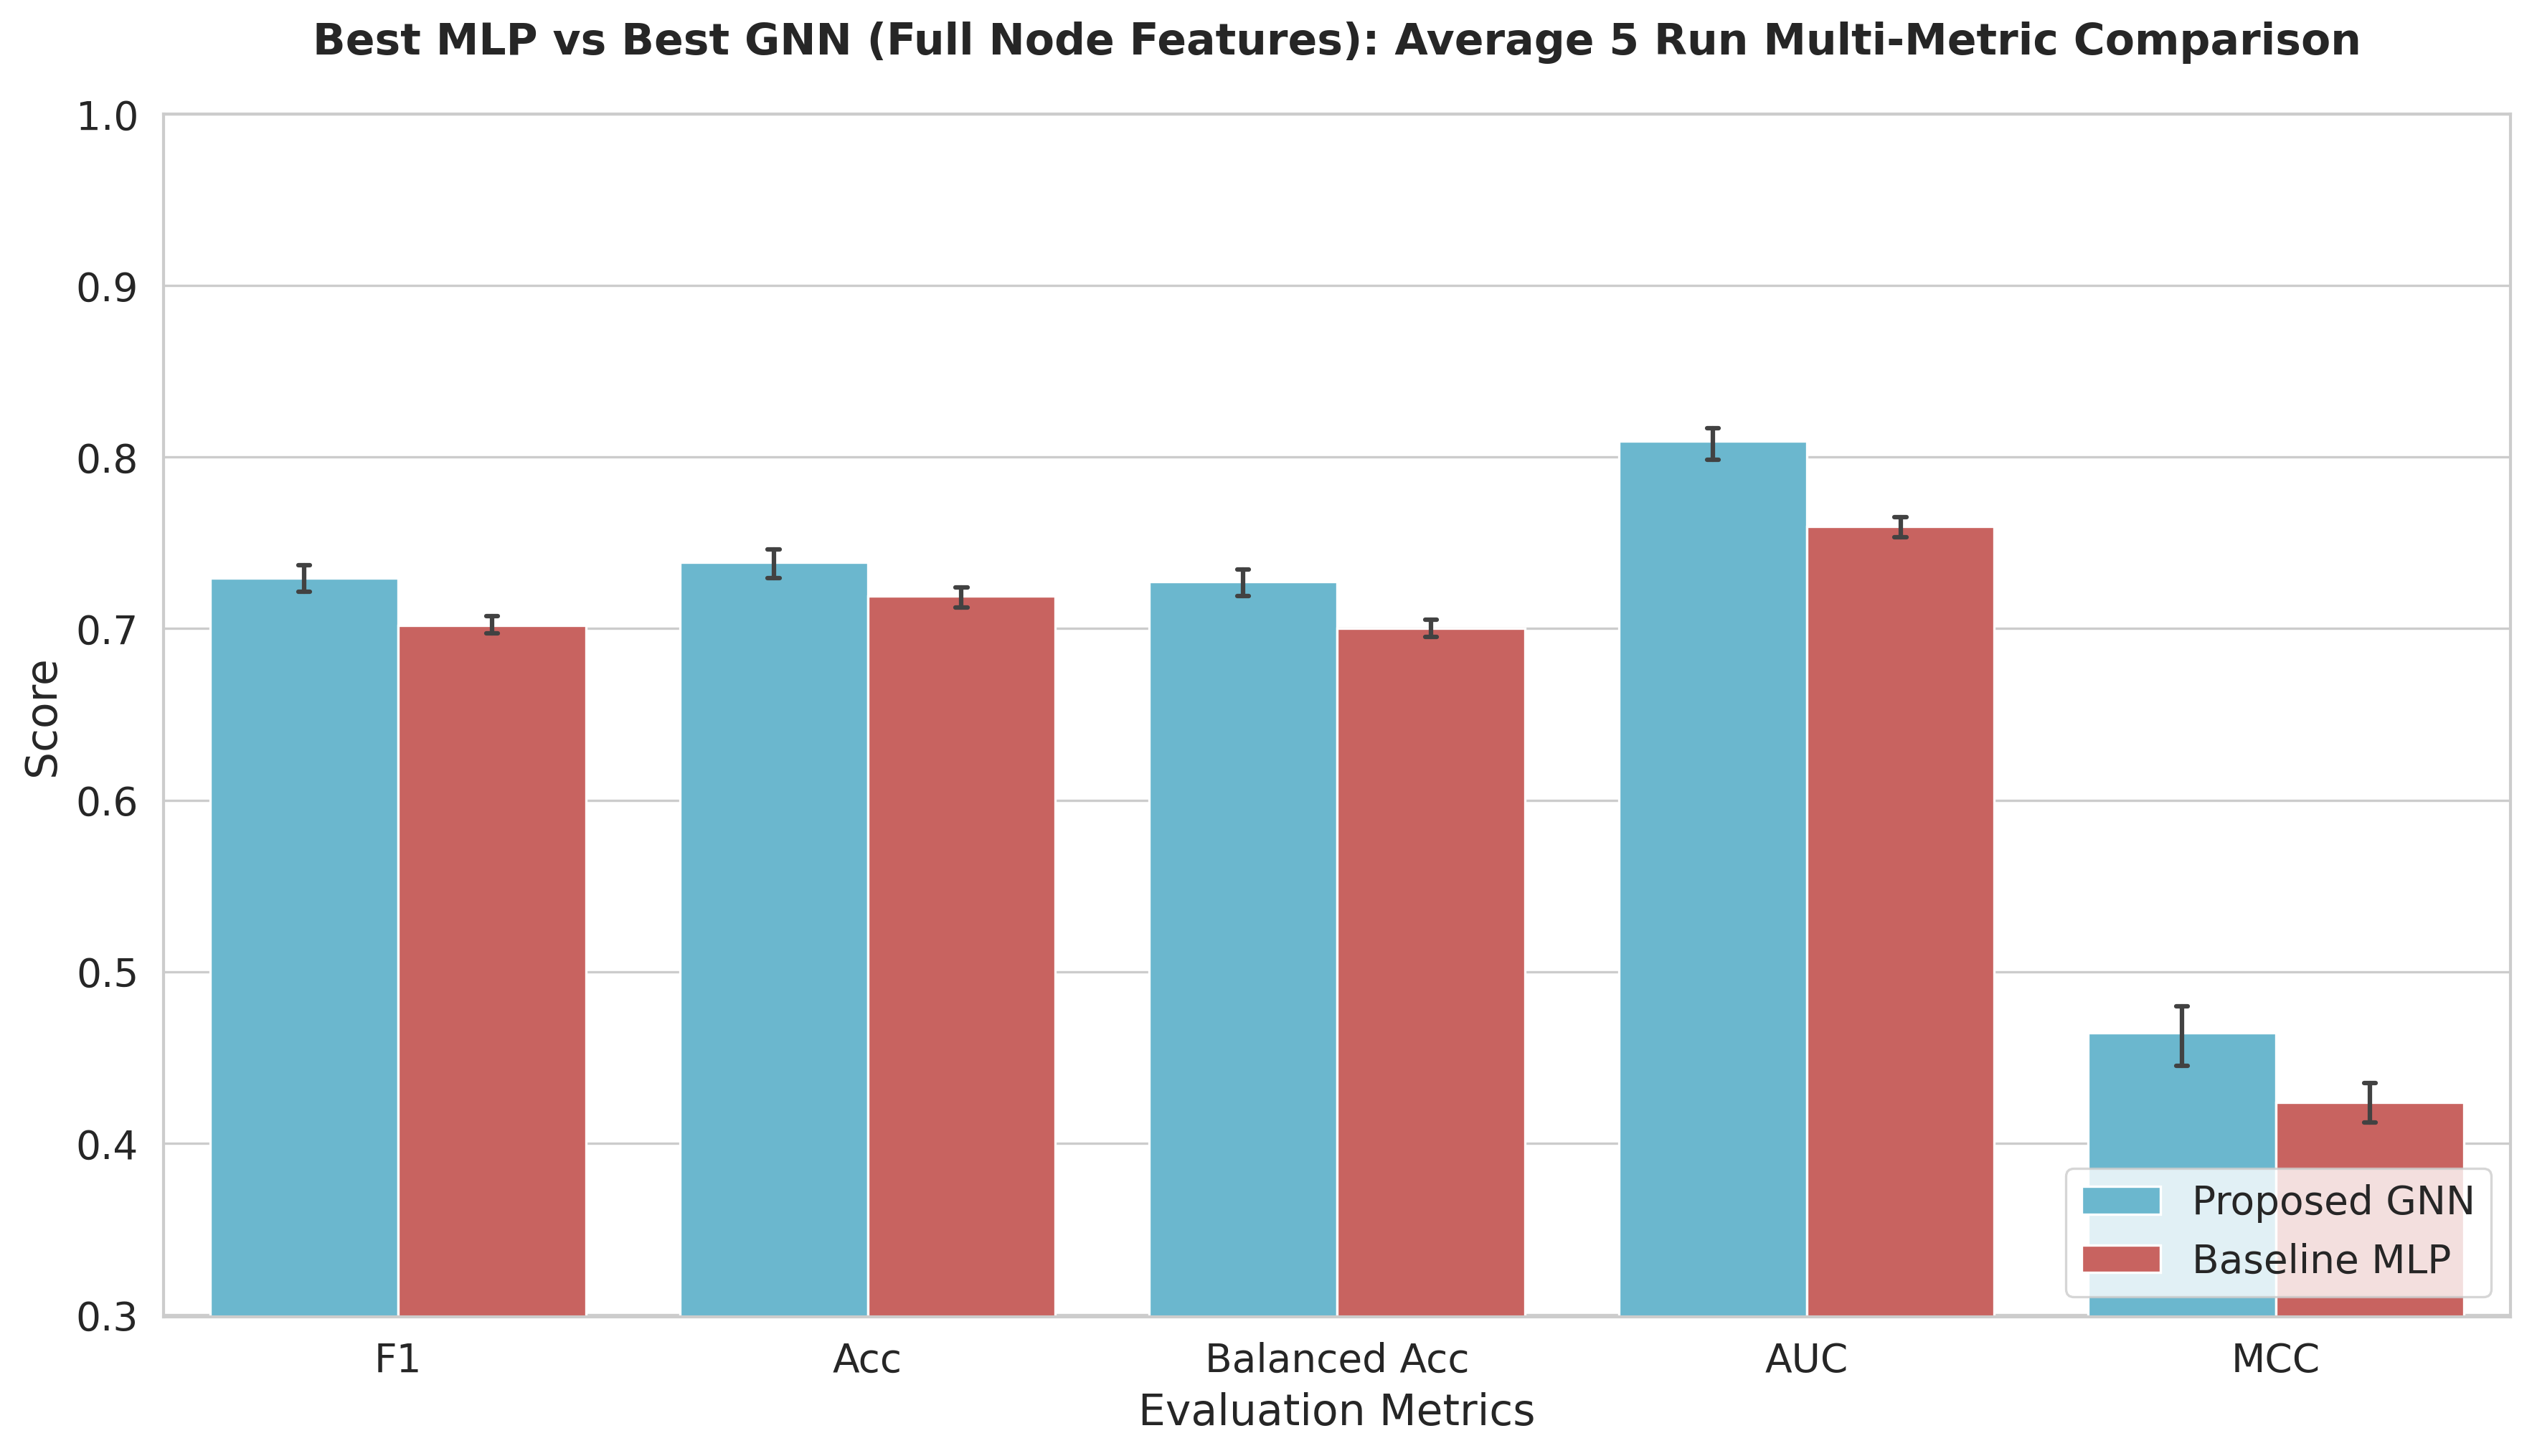


--- Final showdown plots saved to ./outputs/figures ---


In [ ]:
plot_final_showdown(showdown_results_seasonal, OUTPUT_FIGURES_PATH)